# T26 — Beyond `pt_rot`: continent reconstruction with `gplately` instead of hard-coded Euler poles

**Replacehand-rolled `frp.get_pole` + `pmag.pt_rot` continent reconstruction with a proper `gplately` rotation tree, and render the result with pyGMT — a gateway tutorial that contrasts the static-pole approach historically used in the paleomagnetism community with the topological-rotation-model approach the suite is built around.**

## What this notebook produces

Reconstructing the outlines of major continents to a target age is a common opening exercise in plate-tectonic visualisation. The classical approach is to pull an Euler pole from a hard-coded Torsvik et al. (2008) table, apply that single rotation to each continental outline, and render the result. That workflow is fine as a teaching example but has three frictions: the rotation table is frozen at the time the code was written, the output is a polygon outline with no plate-boundary context, and changing the plate model means editing the source code rather than swapping a string.

This notebook reproduces the same end result — Africa and South America at 180 Ma either side of a closing South Atlantic — but uses `gplately`'s rotation tree and `pyGMT` for the rendering. The same arithmetic runs in three lines: load a model via `plate_model_manager`, build a `PlateReconstruction`, and call `PlotTopologies(time=180)`. Swapping `MODEL_NAME` from `"Zahirovic2022"` to `"Merdith2021"` to `"Muller2022"` re-runs the entire workflow against three independently-published rotation models.

**Audience**: undergrad.
**Difficulty**: ★☆☆.

## Learning objectives

- Understand what a plate-tectonic rotation tree is and how it generalises a single hand-coded Euler pole.
- Load any published plate model by name via `plate_model_manager`.
- Reconstruct continental outlines to an arbitrary age and render with pyGMT in three lines.
- Compare two or three published plate models at the same age and see where they agree and where they don't.

## Prerequisites and runtime

- Cao 2024 default (covers 0–1.8 Ga). Other models: Zahirovic 2022 (0–410 Ma), Merdith 2021 (0–1000 Ma), Müller 2022 (0–1000 Ma).
- Python: `gplately`, `pygmt`, `plate_model_manager`, `pygplates`.
- Runtime: < 30 s end-to-end, fetched data not counted.

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np
import gplately
import pygmt
import pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — change the reconstruction age + plate model here

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME          = "Cao2024"      # or "Zahirovic2022", "Merdith2021", "Muller2022"
RECONSTRUCTION_TIME = 180.0          # Ma — Africa–South America just before opening
REGION              = [-110, 60, -65, 30]  # (W, E, S, N) — Atlantic-centred
# ============================================================================


## 1. Load the model and build the reconstruction

In [3]:
# Cell 2 — load model + recon
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
print(f"loaded {MODEL_NAME}")


loaded Cao2024


## 2. Reconstruct continents at the target age and render with pyGMT

The `PlotTopologies` object reconstructs continental polygons, coastlines, ridges, transforms and trenches to whatever time you ask for. The continuous-backbone pattern from CLAUDE.md is used — all topological sections are drawn first in light grey so no boundary segment is missing along the "other-connection" sub-segments.

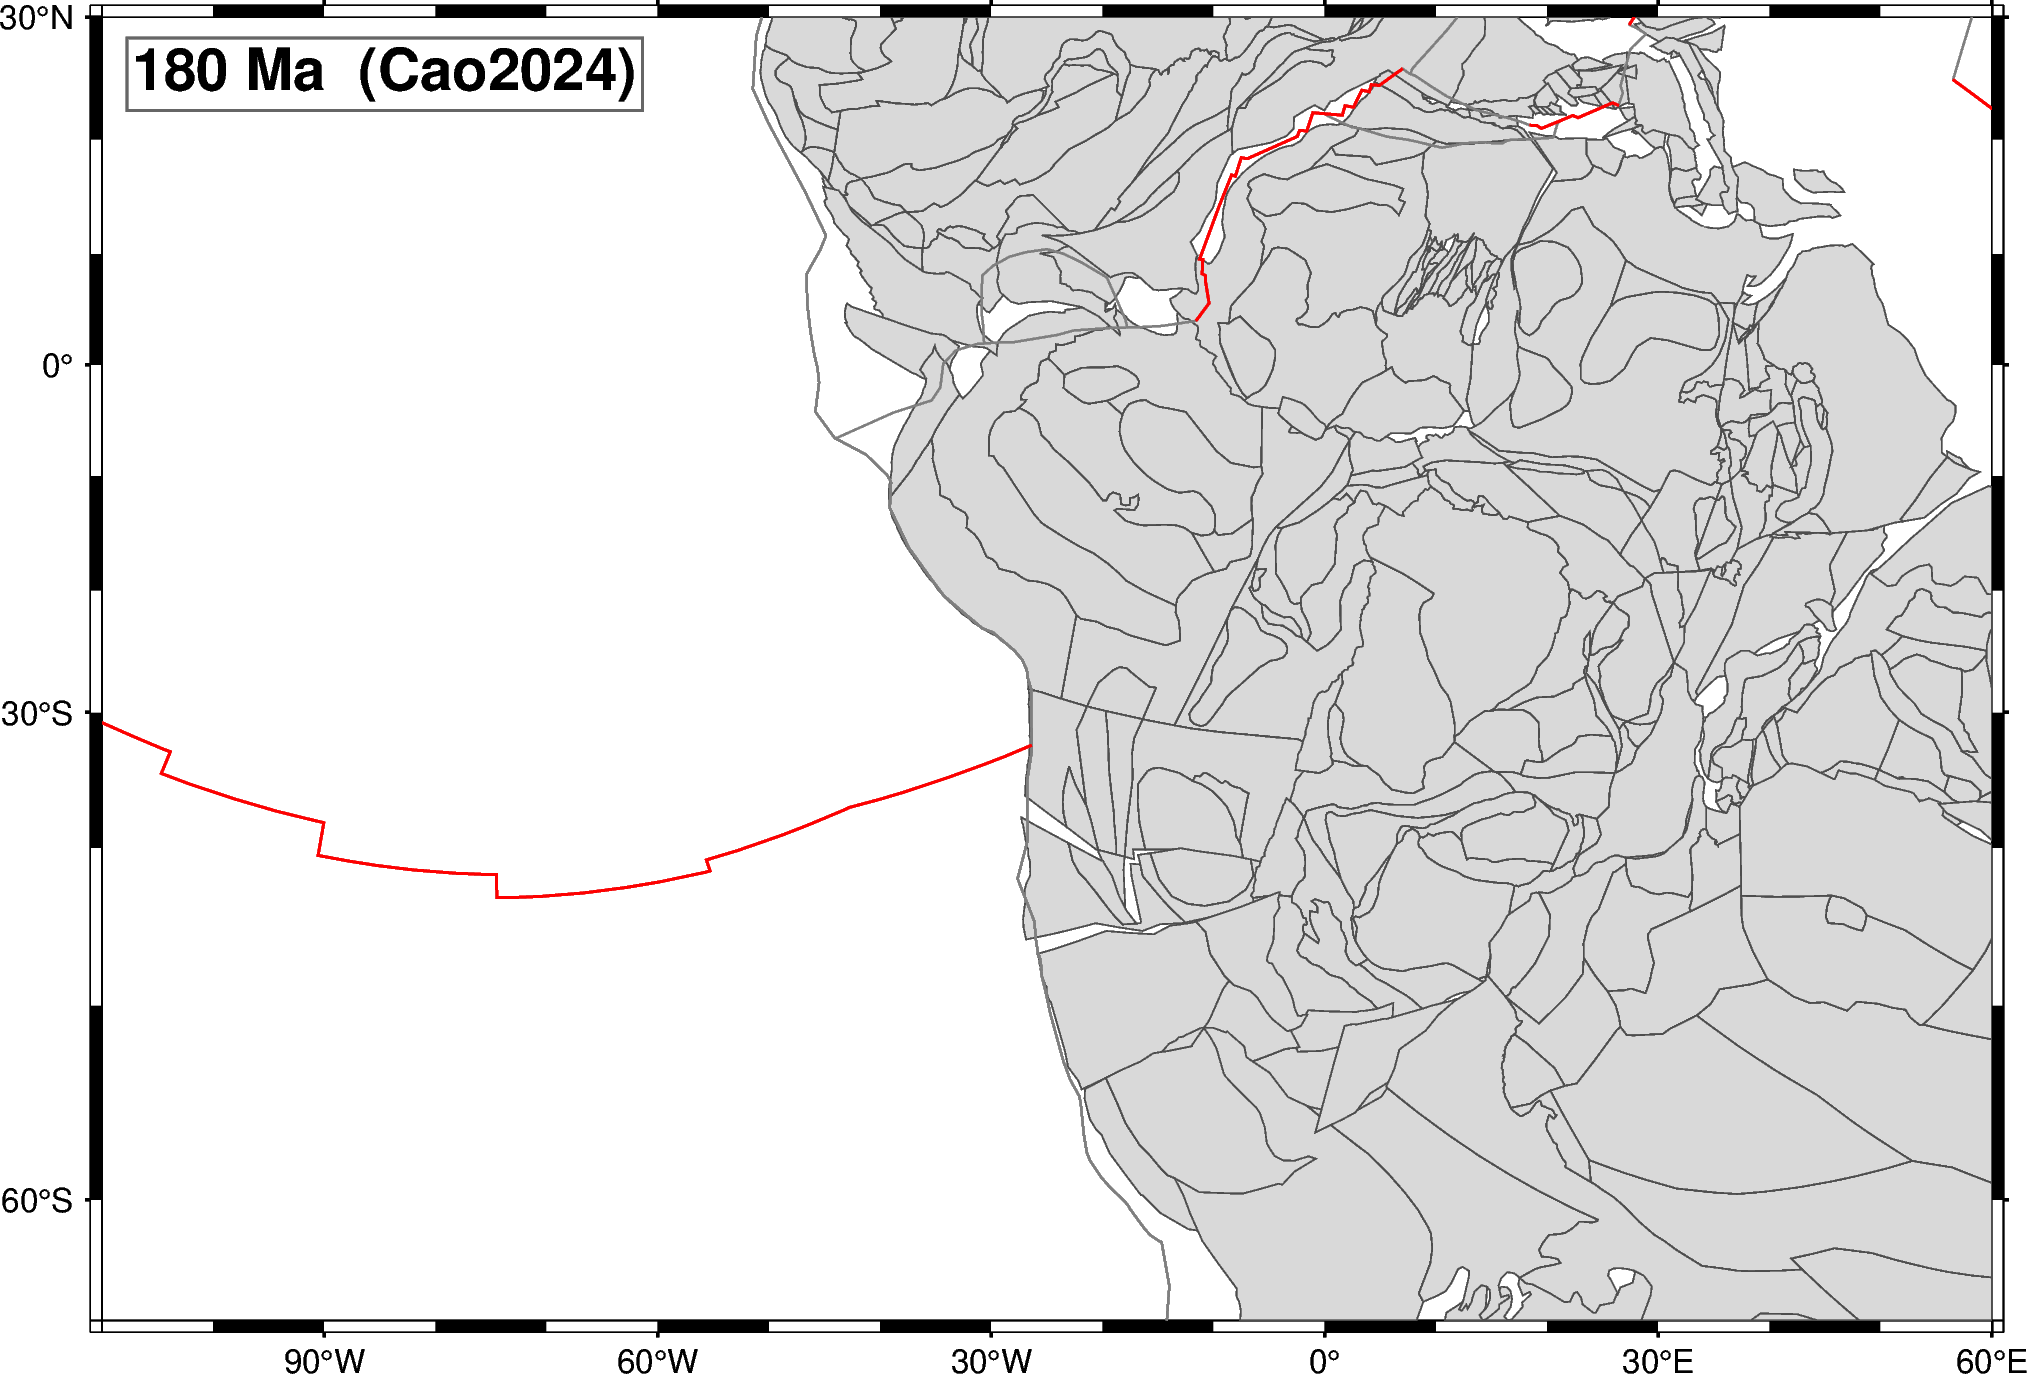

In [4]:
# Cell 3 — render
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(RECONSTRUCTION_TIME),

plot_engine=gplately.PygmtPlotEngine(),
)

fig = pygmt.Figure()
fig.basemap(region=REGION, projection="M16c", frame=["af"])
gplot.plot_continents(fig, fill="gray85", pen="0.3p,gray30")
gplot.plot_all_topological_sections(fig, pen="0.5p,gray50")
gplot.plot_ridges(fig, pen="0.6p,red")

fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=900)
display(HTML('<div style="height:1cm"></div>'))


## What the figure shows

The reconstructed paleo-positions of the chosen continents at `RECONSTRUCTION_TIME` Ma on a Mercator-projected paleo-Earth basemap, with the loaded plate model's continental outlines drawn in gray. The in-frame stamp records which model and age are being rendered.

The point of the demonstration is not the specific configuration of the continents — that is a property of the loaded plate model — but that everything from "pick a model" to "rotate a continent and render it" is two or three lines of code. Compare against the classical hard-coded-Euler-pole workflow described in the motivation paragraph: the rotation table here is not frozen, the output includes plate-boundary context for free, and swapping `MODEL_NAME` to any PMM-registered model regenerates the figure with no further changes.


## Extend this

- **Swap the model.** Change `MODEL_NAME` to `"Merdith2021"` or `"Muller2022"` and re-run. Each model places Africa and South America in a slightly different relative position at 180 Ma. The visible spread is the model-to-model uncertainty at this age.
- **Animate the opening.** Loop `RECONSTRUCTION_TIME` from 180 → 0 Ma in 10 Myr steps and stitch into an MP4 with the recipe from T06.
- **Pair with the paleomagnetic cluster.** T28 reconstructs a present-day point to a deep-time age; T24 builds a paleomagnetic reference frame; T25 compares frames. The continent-rotation primitive demonstrated here is the same operation that underlies all three.

## References

- Torsvik, T.H., Müller, R.D., Van der Voo, R., Steinberger, B. & Gaina, C. (2008). Global plate motion frames: Toward a unified model. *Reviews of Geophysics* 46, RG3004.
- Cao, X., Collins, A.S., Pisarevsky, S., Flament, N., Li, S., Hasterok, D. & Müller, R.D. (2024). Earth's tectonic and plate boundary evolution over 1.8 billion years. *Geoscience Frontiers* 15, 101922. https://doi.org/10.1016/j.gsf.2024.101922
- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3–10.
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515

## See also: rgplates (the R-language equivalent)

Kocsis, Raja, Williams & Dowding's [`rgplates`](https://github.com/GPlates/rgplates) R package offers the same continent / point reconstruction workflow this notebook does, but from R. Vignette 2 in particular (*Reconstructions using modern coordinates, online*) walks through the same back-rotate-a-continent recipe via the GPlates Web Service. The Python and R paths in the GPlates ecosystem are complementary — `rgplates (https://github.com/gplates/rgplates)` is the standard tool for users whose pipelines run through R / `sf` / `chronosphere`; `gplately` is the standard tool for users whose pipelines run through `xarray` / `pygmt` / `gpd` like this notebook does.
